# Milestone 2A — Camera first-surface view

Evidence notebook for Milestone 2A: build perspective pinhole rays, intersect the mesh, and inspect first-surface mask / depth / intensity proxy.

Plan: [`plans/milestone_02/02a_camera_geometry_plan.md`](../../plans/milestone_02/02a_camera_geometry_plan.md). Core ray APIs live in `gummybear.rays`; framing and alignment helpers live in `gummybear_validation.helpers` / `gummybear_validation.plotting`.

## What we check here:

1. **First-surface visibility** — `first_visible_hits` returns a coherent mask (no background leaks, bear silhouette plausible).
2. **Camera pose vs. raster** — the wireframe panel uses the same pinhole basis as `make_pinhole_rays`, so orientation matches the mask/intensity images.
3. **Intensity proxy** — `simple_camera_intensity(..., mode="bdotv")` is a stand-in until M2B appearance; here beam and view both follow the camera forward axis. This is not the final intensity implementation, in fact, it returns constant, but is to check the code path.

## Test mesh

`cad/proto_bear_head.stl` 

## Camera framing

- Place the pinhole on **−Y** at standoff `max(2.35 × 2 × bounding_sphere_radius, 26 mm)` so the camera sits outside the volume. This view should be the prototypical bear view
- Aim at the mesh **centroid**.
- Set square **FOV** from front-facing vertex projections on the unit image plane, inflated by `margin=1.16`.

See `pinhole_camera_framing_mesh` in `gummybear_validation.helpers.camera_helpers`.

In [1]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[dev]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
from gummybear.geometry import inspect_stl
from gummybear.rays.camera import make_camera_rays
from gummybear.rays.visibility import (
    first_visible_hits,
    hits_to_image,
    simple_camera_intensity,
)
from gummybear_validation.helpers import pinhole_camera_framing_mesh
from gummybear_validation.plotting import plot_pinhole_wireframe

In [3]:
import numpy as np

# Load head phantom and derive an auto-framed pinhole (see intro markdown).
inspection = inspect_stl(ROOT / "cad" / "proto_bear_head.stl")
mesh = inspection["mesh"]
summary = inspection["summary"]

cam = pinhole_camera_framing_mesh(mesh)
rays = make_camera_rays(cam)

view_dir = tuple(
    (np.asarray(cam.look_at) - np.asarray(cam.camera_position)).tolist()
)
print(f"look_at={summary['centroid']}")
print(
    f"camera_position={cam.camera_position}  fov_deg={cam.fov_deg:.2f}  "
    f"resolution={cam.resolution}"
)

look_at=[-0.3088165524230124, 0.011123514093597783, 5.1710866813314915]
camera_position=(-0.3088165524230124, 78.79519318462863, 5.1710866813314915)  fov_deg=27.53  resolution=256


In [4]:
# First-surface hit → image maps; intensity proxy uses camera forward for b and v.
valid_mask, hit_depth, hit_faces = first_visible_hits(mesh, rays)

mask_img, depth_img, normal_img = hits_to_image(
    mesh,
    valid_mask,
    hit_depth,
    hit_faces,
    resolution=cam.resolution,
)

intensity_img = simple_camera_intensity(
    mask_img,
    beam_direction=view_dir,
    view_direction=view_dir,
    mode="bdotv",
)

print(f"visible pixels={int(mask_img.sum())} / {mask_img.size}")

visible pixels=22210 / 65536


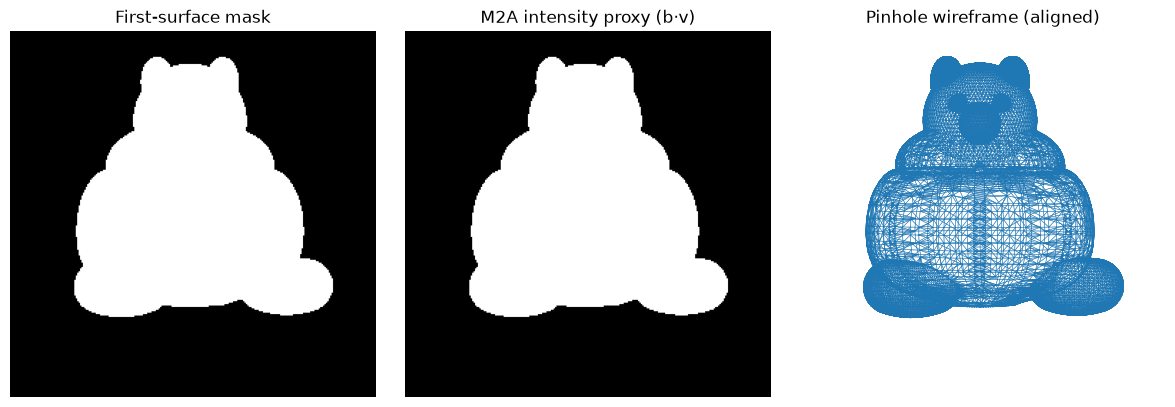

In [5]:
import matplotlib.pyplot as plt

# Mask / proxy raster (origin='lower') plus edge projection in the same pinhole frame.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(mask_img, cmap="gray", origin="lower")
axes[0].set_title("First-surface mask")
axes[0].axis("off")
axes[1].imshow(intensity_img, cmap="gray", origin="lower")
axes[1].set_title("M2A intensity proxy (b·v)")
axes[1].axis("off")
plot_pinhole_wireframe(axes[2], mesh, cam)
axes[2].set_title("Pinhole wireframe (aligned)")
fig.tight_layout()
plt.show()